## Data Exploration


Dieses Skript dient der Datenanalyse und Exploration der Datasets von DocILE und VRDU zur Vorbereitung der Operationalisierung von L1 - L3.

Um den Skript auszuführen müssen die Daten aus den Quellrepositories ausgeführt werden:
- ./scripts/download_dataset_docile.sh
- ./scripts/download_dataset_vrdu.sh

### VRDU: Registration Form

In [48]:
import json
import pandas as pd 

In [49]:
df_registration_form =pd.read_json("../data/vrdu/registration-form/main/dataset.jsonl", lines=True)

df_registration_form.head(5)

,filename,file_path,ocr,annotations
0,19410222_DLA Piper US LLP_Amendment_Amendment.pdf,./pdfs/19410222_DLA Piper US LLP_Amendment_Ame...,{'text': 'i OMB NO. 1124-0003 U.S. Department ...,"[[registration_num, [['3712\n', [0, 0.46376812..."
1,"19620326_Austrian Tourist Office, Inc._Amendme...","./pdfs/19620326_Austrian Tourist Office, Inc._...",{'text': 'Budget Bureau No. 42 9226.3 proval E...,"[[registration_num, [['495\n', [0, 0.83961117,..."
2,19630401_Arab Information Center_Amendment_Ame...,./pdfs/19630401_Arab Information Center_Amendm...,{'text': 'App Budge Bureau No. 226.3 Expires J...,"[[registration_num, [['876\n', [0, 0.809428270..."
3,19630601_Arab Information Center_Amendment_Ame...,./pdfs/19630601_Arab Information Center_Amendm...,{'text': 'Feet Bureau No. 43-P226.3 val Expire...,"[[registration_num, [['876\n', [0, 0.79343861,..."
4,19630701_KOTRA_Amendment_Amendment.pdf,./pdfs/19630701_KOTRA_Amendment_Amendment.pdf,{'text': 'Budget Burd Jo. 43-R227.1 Approval E...,"[[registration_num, [['16/9\n', [0, 0.78614825..."


In [50]:
df_registration_form.describe()

,filename,file_path,ocr,annotations
count,1915,1915,1915,1915
unique,1915,1915,1915,1915
top,19410222_DLA Piper US LLP_Amendment_Amendment.pdf,./pdfs/19410222_DLA Piper US LLP_Amendment_Ame...,{'text': 'i OMB NO. 1124-0003 U.S. Department ...,"[[registration_num, [['3712\n', [0, 0.46376812..."
freq,1,1,1,1


In [51]:
df_registration_form.ocr[0]["text"][0:250]

'i\nOMB NO. 1124-0003\nU.S. Department of Justice\nWashington, DC 20530\nAmendment to Registration Statement\nPursuant to the Foreign Agents Registration Act of 1938, as amended\nPrivacy Act Statement. The filing of this document is required by the Foreign '

In [52]:
def parse_vrdu_annotations(annotations_list):
    """
    Entpackt die verschachtelte VRDU-Annotations-Liste in ein flaches Dictionary.
    Fängt flache Strings, hierarchische Werte UND hierarchische Keys sicher ab.
    """
    extracted_data = {}
    
    # Sicherstellen, dass es überhaupt eine Liste ist
    if not isinstance(annotations_list, list):
        return extracted_data
        
    for entity in annotations_list:
        if len(entity) >= 2:
            raw_key = entity[0]
            
            if isinstance(raw_key, list):
                entity_name = "___".join([str(k) for k in raw_key])
            else:
                entity_name = str(raw_key)
                
            entity_values = entity[1]
            
            # Prüfen, ob Werte vorhanden sind
            if isinstance(entity_values, list) and len(entity_values) > 0:
                first_val = entity_values[0][0]
                
                if isinstance(first_val, str):
                    extracted_data[entity_name] = first_val.strip()
                    
                elif isinstance(first_val, list):
                    extracted_data[entity_name] = f"<HIERARCHISCHE_LISTE_MIT_{len(first_val)}_ELEMENTEN>"
                    
                else:
                    extracted_data[entity_name] = str(first_val)
                    
    return extracted_data

def evaluate_complexity(df, dataset_name):
    """
    Berechnet die Metriken zum empirischen Beweis der Dokumentenkomplexität (L2 vs L3).
    """
    print(f"Analyse: {dataset_name}")
    
    df['parsed_annotations'] = df['annotations'].apply(parse_vrdu_annotations)
    
    # Entitätsdichte berechnen 
    df['entity_count'] = df['parsed_annotations'].apply(len)
    avg_entities = df['entity_count'].mean()
    
    # Prüfung auf hierarchische Felder
    has_line_items = any(
        df['parsed_annotations'].apply(
            lambda x: any(str(v).startswith("<HIERARCHISCHE") for v in x.values()) or 
                      any("___" in str(k) for k in x.keys())
        )
    )
    
    print(f"Durchschnittliche Entitätsdichte: {avg_entities:.2f} Felder pro Dokument")
    print(f"Enthält hierarchische Tabellendaten (Line-Items): {'Ja (-> L3 Charakteristik)' if has_line_items else 'Nein (-> L1/L2 Charakteristik)'}")
    
    # Beispiel-Ausdruck des ersten Dokuments
    print("\nBeispiel-Extraktion (Ground Truth des 1. Dokuments):")
    print(json.dumps(df['parsed_annotations'].iloc[0], indent=2, ensure_ascii=False))
    print("\n")
    
    return df

df_registration_form = evaluate_complexity(df_registration_form, "Registration Forms (L2 Kandidat)")

Analyse: Registration Forms (L2 Kandidat)
Durchschnittliche Entitätsdichte: 4.61 Felder pro Dokument
Enthält hierarchische Tabellendaten (Line-Items): Nein (-> L1/L2 Charakteristik)

Beispiel-Extraktion (Ground Truth des 1. Dokuments):
{
  "registration_num": "3712",
  "registrant_name": "DLA Piper US LLP",
  "file_date": "July 16, 2008"
}




### VRDU: Ad-Buy-Form

In [2]:
import pandas as pd 

df_ad_buy_form =pd.read_json("../data/vrdu/ad-buy-form/main/dataset.jsonl", lines=True)

df_ad_buy_form.head(5)

,filename,file_path,ocr,annotations
0,00a83bbc-0101-f092-4bd7-e75f315e8f14.pdf,./pdfs/00a83bbc-0101-f092-4bd7-e75f315e8f14.pdf,{'text': 'Page 1 of 2 INVOICE FOX Remit Addres...,"[[property, [['KMSP\n', [0, 0.14883721, 0.0662..."
1,00c29ad8-c88b-b3bb-1a39-3267e47c7a88.pdf,./pdfs/00c29ad8-c88b-b3bb-1a39-3267e47c7a88.pdf,{'text': 'Page 1 of 1 INVOICE DUE ATE 2436316-...,"[[property, [['WXXA\n', [0, 0.14763948, 0.0677..."
2,00c3353e-a25f-574a-a9db-39a41579895a.pdf,./pdfs/00c3353e-a25f-574a-a9db-39a41579895a.pdf,{'text': 'Print Date 02/28/20 14:21:20 Page 1 ...,"[[contract_num, [['14086\n', [0, 0.27917981000..."
3,01250d60-2a0a-0c93-5a18-9f1f195fdc1a.pdf,./pdfs/01250d60-2a0a-0c93-5a18-9f1f195fdc1a.pdf,{'text': 'Page 1 of 4 INVOICE Advertiser 4 Rem...,"[[property, [['KCNC-TV\n', [0, 0.14883721, 0.0..."
4,0179ed96-6b64-eb8b-07c1-3214262dec0c.pdf,./pdfs/0179ed96-6b64-eb8b-07c1-3214262dec0c.pdf,{'text': 'Contract # Date Entered Schedule Dat...,"[[contract_num, [['575746\n', [0, 0.3472609200..."


In [4]:
df_ad_buy_form.annotations.describe()

count                                                   641
unique                                                  641
top       [[property, [['KMSP\n', [0, 0.14883721, 0.0662...
freq                                                      1
Name: annotations, dtype: object

In [5]:
df_ad_buy_form.annotations[0]

[['property',
  [['KMSP\n',
    [0, 0.14883721, 0.066215202, 0.19011629, 0.086531229],
    [[39, 44]]],
   ['KMSP\n',
    [0, 0.54021317, 0.16802508, 0.57994187, 0.18432602],
    [[406, 411]]],
   ['KMSP\n',
    [1, 0.14937425000000001, 0.068443052, 0.19095679999999998, 0.086729363],
    [[2541, 2546]]],
   ['KMSP\n',
    [1, 0.54004037, 0.16804528, 0.5740242, 0.1845886],
    [[2908, 2913]]]]],
 ['tv_address',
  [['4614 Collection Center Drive\nChicago, IL 60693\n',
    [0,
     0.14593023,
     0.08728367100000001,
     0.32558139999999997,
     0.12942062000000001],
    [[44, 91]]],
   ['4614 Collection Center Drive\nChicago, IL 60693\n',
    [1, 0.1481631, 0.088819228, 0.32700849, 0.12957157],
    [[2546, 2593]]]]],
 ['advertiser',
  [['Michael Bloomberg 2020, Inc\n',
    [0, 0.54118216, 0.09090909400000001, 0.67635661, 0.10721003],
    [[171, 199]]],
   ['Michael Bloomberg 2020, Inc\n',
    [1, 0.53835803, 0.088811494, 0.67664874, 0.10666087],
    [[2673, 2701]]]]],
 ['product',
  

In [6]:
import pandas as pd
import numpy as np

# Daten laden (Pfad entsprechend anpassen)
# df_ad_buy_form = pd.read_json("../data/vrdu/ad-buy-form/main/dataset.jsonl", lines=True)


def analyze_document_structure(annotations):
    """
    Extrahiert die vorhandenen Felder und den TV-Sender (Property)
    als Proxy für das Layout-Template aus den Annotationen.
    """
    fields = []
    template_proxy = "Unknown_Template"

    for anno in annotations:
        # Prüfung auf einfache vs. hierarchische Entitäten
        if isinstance(anno[0], str):
            field_name = anno[0]
            fields.append(field_name)

            # Das 'property' Feld (Senderkürzel) dient als Indikator für das Template
            if field_name == "property" and len(anno[1]) > 0:
                template_proxy = anno[1][0][0].strip()

        elif isinstance(anno[0], list):
            # Hierarchische Felder (Line Items) zusammenfassen
            hierarchical_name = "_".join(anno[0])
            fields.append(hierarchical_name)

    # Wir sortieren die Felder als Tuple, um sie vergleichbar (hashable) zu machen
    return pd.Series(
        {
            "schema_signature": tuple(sorted(fields)),
            "num_fields": len(fields),
            "template_id": template_proxy,
        }
    )


print("--- Starte Analyse der Ad-buy Forms ---")

# 1. Metadaten extrahieren
df_meta = df_ad_buy_form["annotations"].apply(analyze_document_structure)
df_analysis = pd.concat([df_ad_buy_form, df_meta], axis=1)

# 2. Auswertung der Schema-Konsistenz (Interne Validität)
print("\n### 1. Überprüfung der Schema-Konsistenz ###")
total_docs = len(df_analysis)
unique_schemas = df_analysis["schema_signature"].nunique()

print(f"Gesamtanzahl Dokumente: {total_docs}")
print(f"Anzahl unterschiedlicher Schema-Signaturen: {unique_schemas}")

# Zeige die häufigsten Schema-Kombinationen
print("\nDie 3 häufigsten Feld-Kombinationen (Schema-Signaturen):")
schema_counts = df_analysis["schema_signature"].value_counts().head(3)
for schema, count in schema_counts.items():
    percentage = (count / total_docs) * 100
    print(f"- {count} Dokumente ({percentage:.1f}%): {schema}")

# 3. Auswertung der Template-Varianz (Machbarkeit L1-L3)
print("\n### 2. Überprüfung der Template-Varianz (für L1, L2, L3) ###")
template_counts = df_analysis["template_id"].value_counts()
total_templates = len(template_counts)

print(f"Anzahl identifizierter Layout-Templates (TV-Sender): {total_templates}")

# Kriterien für L1, L2 und L3 prüfen
print("\nSimulation der Experiment-Splits:")

# L1: Single Template (Wir brauchen ein Template mit vielen Dokumenten für Train/Test)
l1_candidates = template_counts[template_counts >= 50]
if not l1_candidates.empty:
    print(f"[OK] L1 (Single Template) machbar. Kandidaten mit >50 Dokumenten:")
    print(l1_candidates.head(3).to_string())
else:
    print(
        f"[WARNUNG] Kein einzelnes Template hat genug Dokumente für einen robusten L1 Split."
    )

# L2 & L3: Mixed & Unseen Templates
if total_templates > 10:
    print(
        f"\n[OK] L2 & L3 machbar. Ausreichend Templates ({total_templates}) vorhanden."
    )

    # Beispielhafter Split
    templates_list = template_counts.index.tolist()
    np.random.seed(42)
    np.random.shuffle(templates_list)

    l2_train_test_templates = templates_list[: int(total_templates * 0.7)]
    l3_unseen_templates = templates_list[int(total_templates * 0.7) :]

    l2_docs = df_analysis[
        df_analysis["template_id"].isin(l2_train_test_templates)
    ].shape[0]
    l3_docs = df_analysis[df_analysis["template_id"].isin(l3_unseen_templates)].shape[0]

    print(
        f"- L2 (Mixed Template) Pool: {len(l2_train_test_templates)} Templates ({l2_docs} Dokumente)"
    )
    print(
        f"- L3 (Unseen Template) Pool: {len(l3_unseen_templates)} Templates ({l3_docs} Dokumente, strikt vom Training getrennt)"
    )
else:
    print(
        f"\n[WARNUNG] Zu wenige Templates ({total_templates}), um L2 und L3 sauber zu trennen."
    )

--- Starte Analyse der Ad-buy Forms ---

### 1. Überprüfung der Schema-Konsistenz ###
Gesamtanzahl Dokumente: 641
Anzahl unterschiedlicher Schema-Signaturen: 513

Die 3 häufigsten Feld-Kombinationen (Schema-Signaturen):
- 11 Dokumente (1.7%): ('advertiser', 'contract_num', 'flight_from', 'flight_to', 'gross_amount', 'product', 'program_start_date_program_end_date_program_desc_channel', 'property', 'tv_address')
- 7 Dokumente (1.1%): ('advertiser', 'channel_program_desc_program_start_date_program_end_date', 'channel_program_desc_program_start_date_program_end_date', 'channel_program_desc_program_start_date_program_end_date', 'contract_num', 'flight_from', 'flight_to', 'gross_amount', 'product', 'property', 'tv_address')
- 6 Dokumente (0.9%): ('advertiser', 'agency', 'contract_num', 'flight_from', 'flight_to', 'gross_amount', 'product', 'program_desc_sub_amount', 'program_desc_sub_amount', 'tv_address')

### 2. Überprüfung der Template-Varianz (für L1, L2, L3) ###
Anzahl identifizierter 

In [54]:
df_ad_buy_form = evaluate_complexity(df_ad_buy_form, "Ad-Buy Forms (L3 Kandidat)")

Analyse: Ad-Buy Forms (L3 Kandidat)
Durchschnittliche Entitätsdichte: 10.30 Felder pro Dokument
Enthält hierarchische Tabellendaten (Line-Items): Ja (-> L3 Charakteristik)

Beispiel-Extraktion (Ground Truth des 1. Dokuments):
{
  "property": "KMSP",
  "tv_address": "4614 Collection Center Drive\nChicago, IL 60693",
  "advertiser": "Michael Bloomberg 2020, Inc",
  "product": "MIKE BLOOMBERG 2020 INC",
  "contract_num": "950658",
  "flight_to": "03/29/20",
  "flight_from": "12/30/19",
  "gross_amount": "$5,625.00",
  "channel___program_desc___program_start_date___program_end_date": "<HIERARCHISCHE_LISTE_MIT_3_ELEMENTEN>",
  "channel___program_desc": "<HIERARCHISCHE_LISTE_MIT_3_ELEMENTEN>"
}




In [1]:
df_ad_buy_form.annotations

NameError: name 'df_ad_buy_form' is not defined

### Docile

In [55]:
with open("../data/docile/annotations/0a1bf0ac3db840e1be10e064.json", "r") as f:
    data = json.load(f)

# Gezielt den Teil in einen DataFrame umwandeln, der dich interessiert
df_fields = pd.json_normalize(data, record_path=['field_extractions'])

df_line_items = pd.json_normalize(data, record_path=['line_item_extractions'])

print(df_fields.head())

                                                bbox  \
0  [0.6491683867555995, 0.09200664549297072, 0.72...   
1  [0.7442520598420361, 0.17343781449249657, 0.81...   
2  [0.5967741935483871, 0.8266832917705735, 0.703...   
3  [0.09576772828849729, 0.1729090406678243, 0.30...   
4  [0.09713583869261867, 0.17238026684315205, 0.3...   

                  fieldtype  page  \
0               document_id     0   
1               vendor_name     0   
2               vendor_name     0   
3     customer_billing_name     0   
4  customer_billing_address     0   

                                                text  
0                                         1408014338  
1                                            WGTY-FM  
2                                     agency(and MBS  
3    MAIN STREET MEDIA GROUP\nSENATE LEADERSHIP FUND  
4  MAIN STREET MEDIA GROUP\nSENATE LEADERSHIP FUN...  


In [56]:
import json

df_ocr = pd.read_json("../data/docile/ocr/0a1bf0ac3db840e1be10e064.json", lines=True)

pretty_json = json.dumps(df_ocr.pages[0], indent=2)
pretty_json.splitlines()[:50]

['[',
 '  {',
 '    "page_idx": 0,',
 '    "dimensions": [',
 '      1684,',
 '      1302',
 '    ],',
 '    "orientation": {',
 '      "value": null,',
 '      "confidence": null',
 '    },',
 '    "language": {',
 '      "value": null,',
 '      "confidence": null',
 '    },',
 '    "blocks": [',
 '      {',
 '        "geometry": [',
 '          [',
 '            0.2763671875,',
 '            0.076171875',
 '          ],',
 '          [',
 '            0.4521484375,',
 '            0.130859375',
 '          ]',
 '        ],',
 '        "lines": [',
 '          {',
 '            "geometry": [',
 '              [',
 '                0.2763671875,',
 '                0.076171875',
 '              ],',
 '              [',
 '                0.4521484375,',
 '                0.09765625',
 '              ]',
 '            ],',
 '            "words": [',
 '              {',
 '                "value": "Broadcast",',
 '                "confidence": 0.9957334399223321,',
 '                "geom

In [57]:
with open("../data/docile/annotations/0a1bf0ac3db840e1be10e064.json", "r") as f:
    data = json.load(f)

pretty_json = json.dumps(data["field_extractions"], indent=2)
print("\n".join(pretty_json.splitlines()[:25]))

[
  {
    "bbox": [
      0.6491683867555995,
      0.09200664549297072,
      0.7264666245884581,
      0.10469721728510462
    ],
    "fieldtype": "document_id",
    "page": 0,
    "text": "1408014338"
  },
  {
    "bbox": [
      0.7442520598420361,
      0.17343781449249657,
      0.8126575800481056,
      0.18507083863528595
    ],
    "fieldtype": "vendor_name",
    "page": 0,
    "text": "WGTY-FM"
  },
  {
    "bbox": [


In [58]:
import os
import glob
import json
import pandas as pd

def evaluate_docile_complexity(annotations_dir):
    print("Analyse: Docile (L3 Kandidat)")
    
    metrics = []
    file_paths = glob.glob(os.path.join(annotations_dir, "*.json"))
    
    if not file_paths:
        print("Keine JSON-Dateien im angegebenen Pfad gefunden.")
        return
        
    for file in file_paths:
        with open(file, "r") as f:
            data = json.load(f)
            
        field_extractions = data.get("field_extractions", [])
        num_fields = len(field_extractions)
        
        line_item_extractions = data.get("line_item_extractions", [])
        num_line_item_cells = len(line_item_extractions)
        
        unique_rows = len(set(item.get("line_item_id") for item in line_item_extractions))
        
        metrics.append({
            "filename": os.path.basename(file),
            "num_fields": num_fields,
            "num_line_item_cells": num_line_item_cells,
            "num_table_rows": unique_rows
        })
        
    df_metrics = pd.DataFrame(metrics)
    
    avg_fields = df_metrics['num_fields'].mean()
    avg_table_rows = df_metrics['num_table_rows'].mean()
    docs_with_tables = (df_metrics['num_table_rows'] > 0).mean() * 100
    
    print(f"Analysierte Dokumente: {len(df_metrics)}")
    print(f"Durchschnittliche Entitätsdichte (Kopfdaten): {avg_fields:.2f} Felder pro Dokument")
    print(f"Durchschnittliche Tabellenzeilen: {avg_table_rows:.2f} Zeilen pro Dokument")
    print(f"Enthält hierarchische Tabellendaten (Line-Items): Ja ({docs_with_tables:.1f}% der Dokumente)")
    
    return df_metrics

df_docile_metrics = evaluate_docile_complexity("../data/docile/annotations/")
df_docile_metrics.head()

Analyse: Docile (L3 Kandidat)
Analysierte Dokumente: 5680
Durchschnittliche Entitätsdichte (Kopfdaten): 12.59 Felder pro Dokument
Durchschnittliche Tabellenzeilen: 6.81 Zeilen pro Dokument
Enthält hierarchische Tabellendaten (Line-Items): Ja (93.8% der Dokumente)


,filename,num_fields,num_line_item_cells,num_table_rows
0,33bd367db9a4439887f600aa.json,11,44,11
1,183b1a67b9a9413583eb2dcf.json,11,2,1
2,812d1b205fdd41b9b86c8056.json,7,3,1
3,8538e1e4800643c493e119d9.json,22,3,1
4,03632555cc3b4e71b91b793d.json,9,54,9


# Aufteilung von L1 - L3

In [59]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import Document

print(Document.__annotations__)

{'id': <class 'str'>, 'complexity': <class 'str'>, 'content': <class 'str'>, 'metadata': <class 'dict'>}


Ein Dokument für das Experiment wird in folgender Struktur in einem jsonl eingerichtet:

id -> uuid

complexity -> L1, L2, L3

content -> roher Text oder OCR output

metadaten -> dateiname, dateipfad, dateityp

```json
{
    'id': <class 'str'>, 
    'complexity': <class 'str'>, 
    'content': <class 'str'>, 
    'metadata': <class 'dict'>
}
```

### Operationalisierung von L1

In [60]:
with open(
    "../data/vrdu/registration-form/few_shot-splits/FARA-lv1-single_Amendment-train_200-test_300-valid_100-SD_0.json",
    "r"   
) as f:
    l1 = json.load(f)

l1 = l1["train"] + l1["test"] + l1["valid"]

print(l1[0:10])
print(len(l1))

['20170606_Sonoran Policy Group, LLC_Amendment_Amendment.pdf', '20170418_Husch Blackwell, LLP_Amendment_Amendment.pdf', '20060817_MSLGROUP Americas, Inc._Amendment_Amendment.pdf', '19910801_British Virgin Islands Tourist Board_Amendment_Amendment.pdf', '20170927_Kingery, Samet _ Sorini, PLLC_Amendment_Amendment.pdf', '20150601_Cassidy _ Associates, Inc._Amendment_Amendment.pdf', '20080623_Sorini, Samet _ Associates, LLC_Amendment_Amendment.pdf', '20100812_Hill and Knowlton Strategies, LLC_Amendment_Amendment.pdf', '19790601_Quebec Government Office_Amendment_Amendment.pdf', '20141105_Squire Patton Boggs, LLP_Amendment_Amendment.pdf']
600


In [61]:
if len(l1) != len(set(l1)):
    print(f"Original: {len(l1)}, Without dublicates: {len(set(l1))}")
else:
    print("No dublicates")

No dublicates


In [62]:
import json
import uuid
import shutil
from pathlib import Path
import pandas as pd

def export_vrdu_split(
    df: pd.DataFrame,
    data_name: str,
    split_filenames: list,
    complexity_label: str,  
    source_base_dir: Path,
    target_pdf_dir: Path,
    target_jsonl_path: Path,
):
    target_pdf_dir.mkdir(parents=True, exist_ok=True)
    target_jsonl_path.parent.mkdir(parents=True, exist_ok=True)

    documents = []
    missing_files = 0
    not_in_split_count = 0

    for index, row in df.iterrows():
        file_name = row["filename"]

        if file_name not in split_filenames:
            not_in_split_count += 1
            continue

        relative_pdf_path = row["file_path"].replace("./", "")
        source_pdf_path = source_base_dir / relative_pdf_path

        target_pdf_path = target_pdf_dir / file_name

        if source_pdf_path.exists():
            shutil.copy2(source_pdf_path, target_pdf_path)
        else:
            print(
                f"WARNUNG: Quelldatei nicht gefunden übersprungen -> {source_pdf_path}"
            )
            missing_files += 1
            continue

        content_text = ""
        if isinstance(row["ocr"], dict) and "text" in row["ocr"]:
            content_text = row["ocr"]["text"]

        gt = parse_vrdu_annotations(row["annotations"])

        doc = {
            "id": uuid.uuid4().hex,
            "complexity": complexity_label,
            "metadata": {
                "source": f"VRDU {data_name}",
                "document_name": file_name,
                "raw_file_path": str(target_pdf_path),
                "original_file_path": row["file_path"],
            },
            "content": content_text,
            "ground_truth": gt,
            "target_fields": list(gt.keys()),
        }
        documents.append(doc)

    with open(target_jsonl_path, "w", encoding="utf-8") as f:
        for doc in documents:
            f.write(json.dumps(doc, ensure_ascii=False) + "\n")

    print(
        f"{len(documents)} Dokumente für {complexity_label} erfolgreich verarbeitet."
    )
    print(
        f"{not_in_split_count} Dokumente wurden ignoriert (nicht in der übergebenen Liste)."
    )

    if missing_files > 0:
        print(
            f"{missing_files} Dokumente wurden übersprungen (PDF fehlte auf der Festplatte)!"
        )

    return documents


In [63]:

documents_l1_full = export_vrdu_split(
    df=df_registration_form,
    data_name="registration_form",
    split_filenames=l1,
    complexity_label="L1",
    source_base_dir=Path("../data/vrdu/registration-form/main/"),
    target_pdf_dir=Path("../data/pdfs/l1"),
    target_jsonl_path=Path("../data/processed/corpus_l1_full.jsonl"),
)

600 Dokumente für L1 erfolgreich verarbeitet.
1315 Dokumente wurden ignoriert (nicht in der übergebenen Liste).


In [64]:
df_l1_registration_form = pd.read_json("../data/processed/corpus_l1_full.jsonl", lines=True)
df_l1_registration_form.head()

,id,complexity,metadata,content,ground_truth,target_fields
0,e3bfb81bf4664a788185bbbefa27d8bd,L1,"{'source': 'VRDU registration_form', 'document...",Budget Bureau No. 42 9226.3\nproval Expires\ny...,"{'registration_num': '495', 'registrant_name':...","[registration_num, registrant_name, foreign_pr..."
1,0d54990c929c449e8d00e5489bc47ecd,L1,"{'source': 'VRDU registration_form', 'document...","App\nBudge Bureau No. 226.3\nExpires J\ny 31, ...","{'registration_num': '876', 'registrant_name':...","[registration_num, registrant_name, foreign_pr..."
2,81bda60dfadd403a87e83eec9178dfd9,L1,"{'source': 'VRDU registration_form', 'document...","Feet Bureau No. 43-P226.3\nval Expires Ja 31, ...","{'registration_num': '876', 'registrant_name':...","[registration_num, registrant_name, foreign_pr..."
3,6102706659314a51897d26d4bce3baa0,L1,"{'source': 'VRDU registration_form', 'document...",Budget Burd Jo. 43-R227.1\nApproval Expires Ja...,"{'registration_num': '16/9', 'registrant_name'...","[registration_num, registrant_name, foreign_pr..."
4,50dcde7492394da58e0afd36b6083b95,L1,"{'source': 'VRDU registration_form', 'document...","get Bureau No. 43-R 3\noval Expires Janual, 19...",{'registrant_name': 'AUSTRALIAN NATIONAL TRAVE...,"[registrant_name, foreign_principle_name, sign..."


In [65]:
df_l1_registration_form.ground_truth.map(lambda x: list(x.keys()) if isinstance(x, dict) else [])[0:10]

0    [registration_num, registrant_name, foreign_pr...
1    [registration_num, registrant_name, foreign_pr...
2    [registration_num, registrant_name, foreign_pr...
3    [registration_num, registrant_name, foreign_pr...
4    [registrant_name, foreign_principle_name, sign...
5    [registration_num, registrant_name, foreign_pr...
6    [registration_num, registrant_name, foreign_pr...
7    [registration_num, registrant_name, foreign_pr...
8    [registrant_name, foreign_principle_name, file...
9    [registration_num, registrant_name, foreign_pr...
Name: ground_truth, dtype: object

### Operationalisierung von L2

In [66]:
with open(
    "../data/vrdu/registration-form/few_shot-splits/FARA-lv2-mixed_template-train_200-test_300-valid_100-SD_2.json",
    "r",
) as f:
    l2 = json.load(f)

l2 = l2["train"] + l2["test"] + l2["valid"]

print(l2[0:10])
print(len(l2))

['20110912_BLJ Worldwide LTD_Smrikarov, Marc Philip George_Short-Form.pdf', '20170222_Nickles Group, LLC_Amendment_Amendment.pdf', '20161229_Crowell _ Moring International, Ltd._Bacigalupo, Patricia Wu_Short-Form.pdf', '20171010_MSLGROUP Americas, Inc._Harper, Clinton L._Short-Form.pdf', '20160208_Ketchum Inc. NY_Mann, Nicole_Short-Form.pdf', '19920301_Kobe Trade Information Office_Dissemination Report_Dissemination Report.pdf', '19920801_Scottish Enterprise_Dissemination Report_Dissemination Report.pdf', '20150218_Quebec Government Office_Fallecker, Stephane_Short-Form.pdf', '20180112_RunSwitch PR, LLC_Carnahan, Kaylee_Short-Form.pdf', '20070302_Glover Park Group, LLC_Amendment_Amendment.pdf']
600


In [67]:
if len(l2) != len(set(l2)):
    print(f"Original: {len(l2)}, Without dublicates: {len(set(l2))}")
else:
    print("No dublicates")

No dublicates


Überschneidung zwischen L1 und L2 für unser Experiment disjunktieren. Da kein Data Leakage zwischen den beiden Bedingungen stattfinden soll.

In [68]:
dublicates_in_l1_and_l2 = len(df_registration_form["filename"].isin(l1))

dublicates_in_l1_and_l2

1915

In [69]:
df_registration_form_without_l1 = df_registration_form[~df_registration_form['filename'].isin(l1)]

In [70]:
documents_l2_full = export_vrdu_split(
    df=df_registration_form_without_l1,
    data_name="registration-form",
    split_filenames=l2,
    complexity_label="L2",
    source_base_dir=Path("../data/vrdu/registration-form/main/"),
    target_pdf_dir=Path("../data/pdfs/l2"),
    target_jsonl_path=Path("../data/processed/corpus_l2_full.jsonl"),
)

423 Dokumente für L2 erfolgreich verarbeitet.
892 Dokumente wurden ignoriert (nicht in der übergebenen Liste).


In [71]:
df_l2_registration_form = pd.read_json(
    "../data/processed/corpus_l2_full.jsonl", lines=True
)
df_l2_registration_form.head()

,id,complexity,metadata,content,ground_truth,target_fields
0,881ccec7217f4a89b8d3c9c0d61278b4,L2,"{'source': 'VRDU registration-form', 'document...",UNITED STATES DEPARTMENT OF JUSTICE\nWASHINGTO...,"{'registrant_name': 'Quebec Government House',...","[registrant_name, registration_num, signer_nam..."
1,c15f8d4a1cbf4e9181593e12fe381ae9,L2,"{'source': 'VRDU registration-form', 'document...","NY 226\nApproval Expires Oct. 31, 1981\nUNITED...","{'registration_num': '3354', 'registrant_name'...","[registration_num, registrant_name, file_date]"
2,aca703155fce4e22a1569e548a329c2e,L2,"{'source': 'VRDU registration-form', 'document...",OMB No. 1105-0004\nU.S.-Department of Justice\...,"{'registration_num': '1750', 'registrant_name'...","[registration_num, registrant_name, file_date]"
3,d1f7e627e9e543ca9b5b68ce3a55885a,L2,"{'source': 'VRDU registration-form', 'document...","U.S. Department of Justice\nWashington, D.C. 2...",{'registrant_name': 'Singapore Economic Develo...,"[registrant_name, registration_num, foreign_pr..."
4,10c76565febf4008babc04153f604f59,L2,"{'source': 'VRDU registration-form', 'document...",OMB No. 1105-0004\nU.S. Department of Junce\nW...,"{'registrant_name': 'Arnold & Porter', 'regist...","[registrant_name, registration_num, signer_nam..."


### Check Data Leakage

Datenüberschneidung zwischen dem L1 und L2 Datensatz festellen:

In [72]:
l1_docs = set(df_l1_registration_form['metadata'].apply(lambda x: x.get('document_name')))
l2_docs = set(df_l2_registration_form['metadata'].apply(lambda x: x.get('document_name')))

overlap = l1_docs.intersection(l2_docs)

if len(overlap) == 0:
    print("Keine Überschneidungen zwischen L1 und L2. Kein Data Leakage.")
else:
    print(f"{len(overlap)} Dokumente überschneiden sich!")
    print(f"Beispiele für Überschneidungen: {list(overlap)[:5]}")

Keine Überschneidungen zwischen L1 und L2. Kein Data Leakage.


In [73]:
df_l1_registration_form['text_length'] = df_l1_registration_form['content'].apply(len)
df_l2_registration_form['text_length'] = df_l2_registration_form['content'].apply(len)

l1_mean = df_l1_registration_form['text_length'].mean()
l1_std = df_l1_registration_form['text_length'].std()

l2_mean = df_l2_registration_form['text_length'].mean()
l2_std = df_l2_registration_form['text_length'].std()

print("L1 (Single Template):")
print(f"Durchschnittliche Textlänge: {l1_mean:.2f} Zeichen")
print(f"Standardabweichung:          {l1_std:.2f} Zeichen")

print("\nL2 (Mixed Template):")
print(f"Durchschnittliche Textlänge: {l2_mean:.2f} Zeichen")
print(f"Standardabweichung:          {l2_std:.2f} Zeichen")


L1 (Single Template):
Durchschnittliche Textlänge: 4425.57 Zeichen
Standardabweichung:          1116.71 Zeichen

L2 (Mixed Template):
Durchschnittliche Textlänge: 5603.34 Zeichen
Standardabweichung:          1541.77 Zeichen


### Operationalisierung von L3

Für L3 wird eine Stichprobe aus DOCILE und VRDU - ad-buy-form verwendet.

In [74]:
df_ad_buy_form = pd.read_json("../data/vrdu/ad-buy-form/main/dataset.jsonl", lines=True)

df_ad_buy_form.head(5)

,filename,file_path,ocr,annotations
0,00a83bbc-0101-f092-4bd7-e75f315e8f14.pdf,./pdfs/00a83bbc-0101-f092-4bd7-e75f315e8f14.pdf,{'text': 'Page 1 of 2 INVOICE FOX Remit Addres...,"[[property, [['KMSP\n', [0, 0.14883721, 0.0662..."
1,00c29ad8-c88b-b3bb-1a39-3267e47c7a88.pdf,./pdfs/00c29ad8-c88b-b3bb-1a39-3267e47c7a88.pdf,{'text': 'Page 1 of 1 INVOICE DUE ATE 2436316-...,"[[property, [['WXXA\n', [0, 0.14763948, 0.0677..."
2,00c3353e-a25f-574a-a9db-39a41579895a.pdf,./pdfs/00c3353e-a25f-574a-a9db-39a41579895a.pdf,{'text': 'Print Date 02/28/20 14:21:20 Page 1 ...,"[[contract_num, [['14086\n', [0, 0.27917981000..."
3,01250d60-2a0a-0c93-5a18-9f1f195fdc1a.pdf,./pdfs/01250d60-2a0a-0c93-5a18-9f1f195fdc1a.pdf,{'text': 'Page 1 of 4 INVOICE Advertiser 4 Rem...,"[[property, [['KCNC-TV\n', [0, 0.14883721, 0.0..."
4,0179ed96-6b64-eb8b-07c1-3214262dec0c.pdf,./pdfs/0179ed96-6b64-eb8b-07c1-3214262dec0c.pdf,{'text': 'Contract # Date Entered Schedule Dat...,"[[contract_num, [['575746\n', [0, 0.3472609200..."


In [75]:
with open(
    "../data/vrdu/ad-buy-form/few_shot-splits/DeepForm-unk_template-train_200-test_159-valid_100-SD_0.json",
    "r",
) as f:
    l3 = json.load(f)

l3 = l3["train"] + l3["test"] + l3["valid"]
print(l3[0:10])
print(len(l3))

['a65d507b-a4ca-5234-f0f0-90ba2a105c6a.pdf', '8012f928-879f-d133-d539-ac40deb9ca5d.pdf', 'e87504ee-8fcc-951c-0652-0ff54129fa64.pdf', '4add49ba-5a10-92b4-36d4-999b09a9b27a.pdf', 'bc21c8e3-8a42-5d9e-b5a4-28e79aae6c68.pdf', '71810401-8e3b-ff82-5d7d-ba86dae4b684.pdf', '57342711-af76-eec9-60b9-f064be838373.pdf', 'da77aaa0-2540-4aa6-8f25-19be10a1900b.pdf', '161648f7-00b2-bf14-373b-83436d07e037.pdf', '99231788-a487-404b-aeba-3ea9dd2fe3b6.pdf']
459


In [76]:
ad_buy_documents = export_vrdu_split(
    df=df_ad_buy_form,
    data_name="ad-buy-form",
    split_filenames=l3,
    complexity_label="L3",
    source_base_dir=Path("../data/vrdu/ad-buy-form/main/"),
    target_pdf_dir=Path("../data/pdfs/l3"),
    target_jsonl_path=Path("../data/processed/corpus_l3_full.jsonl"),
)

459 Dokumente für L3 erfolgreich verarbeitet.
182 Dokumente wurden ignoriert (nicht in der übergebenen Liste).


### DocILE zu L3 hinzufügen

In [77]:
def standardize_docile_ground_truth(ground_truth):
    """
    Konvertiert DocILE ground_truth Format in das standardisierte Format der VRDU-Daten.
    DocILE hat field_extractions und line_item_extractions, wir machen daraus ein flaches Dict.
    """
    standardized = {}
    
    # Feldextraktion (Kopfdaten)
    if "field_extractions" in ground_truth and isinstance(ground_truth["field_extractions"], list):
        for field in ground_truth["field_extractions"]:
            if isinstance(field, dict) and "fieldtype" in field and "text" in field:
                fieldtype = field["fieldtype"]
                text = field["text"]
                standardized[fieldtype] = text
    
    # Line Items (Tabellendaten)
    if "line_item_extractions" in ground_truth and isinstance(ground_truth["line_item_extractions"], list):
        line_items = ground_truth["line_item_extractions"]
        if line_items:
            standardized["line_items"] = line_items
    
    return standardized


def transform_docile_ocr(ocr_data):
    """
    Transformiert DocILE OCR-Daten in Text wie in transform_ocr_to_text().
    Akzeptiert sowohl bereits konvertierte Strings als auch OCR-Dict-Format.
    """
    if isinstance(ocr_data, str):
        return ocr_data
    
    if not isinstance(ocr_data, dict):
        return ""
    
    full_text = []
    
    for page in ocr_data.get("pages", []):
        for block in page.get("blocks", []):
            for line in block.get("lines", []):
                line_text = " ".join(
                    [word.get("value", "") for word in line.get("words", [])]
                )
                if line_text.strip():
                    full_text.append(line_text)
    
    return "\n".join(full_text)

In [78]:
n_documents_l3 = len(ad_buy_documents)
print(f"Ad-Buy Dokumente generiert: {n_documents_l3}")

docile_output_path = "../data/processed/corpus_l3_full_docile_standardized.jsonl"

with open("../data/docile/train.json", "r") as f:
    docile_names = json.load(f)

docile_documents = []

for doc_name in docile_names[:n_documents_l3]:
    with open(f"../data/docile/annotations/{doc_name}.json", "r") as f_ann:
        annotations = json.load(f_ann)

    with open(f"../data/docile/ocr/{doc_name}.json", "r") as f_ocr:
        ocr = json.load(f_ocr)

    docile_documents.append(
        {
            "id": uuid.uuid4().hex,
            "complexity": "L3",
            "metadata": {
                "source": "DocILE",
                "document_name": doc_name,
                "raw_file_path": f"../data/docile/pdfs/{doc_name}.pdf",
            },
            "content": transform_docile_ocr(ocr),
            "content_ocr_raw": ocr,
            "ground_truth": standardize_docile_ground_truth(annotations),
            "ground_truth_raw": annotations,
            "target_fields": list(standardize_docile_ground_truth(annotations).keys()),
        }
    )

with open(docile_output_path, "w", encoding="utf-8") as f:
    for doc in docile_documents:
        f.write(json.dumps(doc, ensure_ascii=False) + "\n")

print(f"{len(docile_documents)} DocILE-Dokumente standardisiert gespeichert in {docile_output_path}")

Ad-Buy Dokumente generiert: 459
459 DocILE-Dokumente standardisiert gespeichert in ../data/processed/corpus_l3_full_docile_standardized.jsonl


In [79]:
docile_documents[0].get("ground_truth")

{'document_id': '990304502',
 'date_issue': '03/25/99',
 'customer_order_id': '29350',
 'vendor_name': 'BioReliance Testing & Development, Inc.',
 'vendor_address': 'BIORELIANCE- Testing & Development, Inc.\n14920 Broschart Road · Rockville, MD 20850-3349 USA',
 'customer_id': '032070010',
 'customer_billing_name': 'LORILLARD RESEARCH CENTER',
 'customer_billing_address': 'LORILLARD RESEARCH CENTER\nATTN: MS MELANEE BENNETT\n420 ENGLISH STREET\nGREENSBORO, NC 27405',
 'currency_code_amount_due': '$',
 'amount_total_gross': '$21,000.00',
 'amount_due': '$21,000.00',
 'payment_reference': '990304502',
 'payment_terms': 'NET DUE UPON RECEIPT',
 'bank_num': '052001633',
 'account_num': '39 163 63 663',
 'line_items': [{'bbox': [0.09112903225806451,
    0.5161094224924012,
    0.16129032258064516,
    0.5300911854103344],
   'fieldtype': 'line_item_quantity',
   'line_item_id': 1,
   'page': 0,
   'text': '01 . 000'},
  {'bbox': [0.19032258064516128,
    0.5161094224924012,
    0.2169354838

In [80]:
all_l3_documents = ad_buy_documents + docile_documents
l3_full_output_path = "../data/processed/corpus_l3_full.jsonl"

with open(l3_full_output_path, "w", encoding="utf-8") as f:
    for doc in all_l3_documents:
        f.write(json.dumps(doc, ensure_ascii=False) + "\n")

print(
    f"Fertig! {len(all_l3_documents)} Dokumente gespeichert in {l3_full_output_path}"
)

Fertig! 918 Dokumente gespeichert in ../data/processed/corpus_l3_full.jsonl


## Stichprobe ziehen

Pro corpus werden 100 Dokumente randomisiert als 

In [81]:
def create_sample_dataset(input_jsonl, output_jsonl, pdf_dir=None, n_samples=100):
    """Zieht n_samples, speichert final und löscht ungenutzte PDFs (falls pdf_dir angegeben)."""
    print(f"\nVerarbeite {input_jsonl}")

    df = pd.read_json(input_jsonl, lines=True)

    if len(df) > n_samples:
        df = df.sample(n=n_samples, random_state=42)

    print(f"Stichprobe gezogen: {len(df)} Dokumente.")
    df.to_json(output_jsonl, orient="records", lines=True, force_ascii=False)

    # PDFs aufräumen (NUR wenn ein Pfad übergeben wurde, um Originaldaten zu schützen!)
    if pdf_dir:
        keep_pdf_names = set(df["metadata"].apply(lambda x: x.get("document_name")))
        deleted_count = 0
        for pdf_file in Path(pdf_dir).glob("*.pdf"):
            if pdf_file.name not in keep_pdf_names:
                pdf_file.unlink()
                deleted_count += 1
        print(f"Cleanup: {deleted_count} nicht benötigte PDFs aus {pdf_dir} gelöscht.")

    return df

In [96]:
l1_sample_path = "../data/processed/corpus_l1_experiment.jsonl"
l2_sample_path = "../data/processed/corpus_l2_experiment.jsonl"
l3_sample_path = "../data/processed/corpus_l3_experiment.jsonl"

df_l1 = create_sample_dataset(
    "../data/processed/corpus_l1_full.jsonl", l1_sample_path, "../data/pdfs/l1", 100
)
df_l2 = create_sample_dataset(
    "../data/processed/corpus_l2_full.jsonl", l2_sample_path, "../data/pdfs/l2", 100
)

# L3 Stratified Sampling 50/50
df_l3_full = pd.read_json(
    "../data/processed/corpus_l3_full.jsonl", lines=True
)

mask_docile = df_l3_full["metadata"].apply(lambda x: x.get("source")) == "DocILE"
df_l3_docile = df_l3_full[mask_docile]
df_l3_adbuy = df_l3_full[~mask_docile]

sample_docile = df_l3_docile.sample(n=50, random_state=42)
sample_adbuy = df_l3_adbuy.sample(n=50, random_state=42)

df_l3_final = (
    pd.concat([sample_docile, sample_adbuy])
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print(
    f"L3 Stichprobe: {len(sample_docile)} DocILE + {len(sample_adbuy)} Ad-Buy = {len(df_l3_final)} Dokumente."
)

# L3 Speichern
df_l3_final.to_json(l3_sample_path, orient="records", lines=True, force_ascii=False)


Verarbeite ../data/processed/corpus_l1_full.jsonl
Stichprobe gezogen: 100 Dokumente.
Cleanup: 0 nicht benötigte PDFs aus ../data/pdfs/l1 gelöscht.

Verarbeite ../data/processed/corpus_l2_full.jsonl
Stichprobe gezogen: 100 Dokumente.
Cleanup: 0 nicht benötigte PDFs aus ../data/pdfs/l2 gelöscht.
L3 Stichprobe: 50 DocILE + 50 Ad-Buy = 100 Dokumente.


## Untersuchung der Extraction Fields

In [99]:
df_l1.head()

,id,complexity,metadata,content,ground_truth,target_fields
110,b026a9d6293c47d7a699e9910ac35df2,L1,"{'source': 'VRDU registration_form', 'document...","U.S. Department of Justune\nWashington, DC 205...","{'registrant_name': 'Holland & Knight', 'regis...","[registrant_name, registration_num, signer_nam..."
419,a7748473ab724c9e8274b329ce852a5e,L1,"{'source': 'VRDU registration_form', 'document...",Received by NSD/FARA Registration Unit 11/03/2...,"{'registration_num': '5666', 'registrant_name'...","[registration_num, registrant_name, file_date,..."
565,0fd33d40d5ac439ca630340f08d2e153,L1,"{'source': 'VRDU registration_form', 'document...",Received by NSD/FARA Registration Unit 03/08/2...,{'registrant_name': 'S.G.R. LLC Government Rel...,"[registrant_name, registration_num, file_date,..."
77,1e3d711ee1c84963a398b391a7d87bbd,L1,"{'source': 'VRDU registration_form', 'document...","ON\nNo.226\nApproval Expires Oct. 31, 1981\nUN...",{'registrant_name': 'Monaco Government Tourist...,"[registrant_name, registration_num, signer_tit..."
181,2104c8831c9b4970a39773c461a9972a,L1,"{'source': 'VRDU registration_form', 'document...","U.S. Department of Justice\nWashington, DC 205...","{'registrant_name': 'PATTON BOGGS LLP', 'regis...","[registrant_name, registration_num, signer_nam..."


In [104]:
def analyze_fairness(df, label):
    column_name = "target_fields"

    if column_name not in df.columns:
        print(f"Fehler: Spalte '{column_name}' nicht im Dataset {label} gefunden!\n")
        return

    counts = df[column_name].apply(
        lambda x: len(x) if isinstance(x, (list, dict)) else 0
    )

    def extract_keys(x):
        if isinstance(x, dict):
            return list(x.keys())
        if isinstance(x, list):
            return x
        return []

    all_fields_list = df[column_name].apply(extract_keys)

    all_fields = set([field for sublist in all_fields_list for field in sublist])

    print(f"Analyse Komplexität {label}:")
    print(f"Durchschnittliche Felder pro Dok: {counts.mean():.2f}")
    print(f"Max Felder: {counts.max()} | Min Felder: {counts.min()}")
    print(f"Unique top 10 Field Names: {', '.join(sorted(list(all_fields))[:10])}\n")


# Anwendung
analyze_fairness(df_l1, "L1")
analyze_fairness(df_l2, "L2")
analyze_fairness(df_l3_final, "L3")

Analyse Komplexität L1:
Durchschnittliche Felder pro Dok: 3.99
Max Felder: 5 | Min Felder: 2
Unique top 10 Field Names: file_date, foreign_principle_name, registrant_name, registration_num, signer_name, signer_title

Analyse Komplexität L2:
Durchschnittliche Felder pro Dok: 4.95
Max Felder: 6 | Min Felder: 3
Unique top 10 Field Names: file_date, foreign_principle_name, registrant_name, registration_num, signer_name, signer_title

Analyse Komplexität L3:
Durchschnittliche Felder pro Dok: 10.82
Max Felder: 20 | Min Felder: 5
Unique top 10 Field Names: account_num, advertiser, agency, amount_due, amount_paid, amount_total_gross, amount_total_net, amount_total_tax, bank_num, channel



# Further Data Exploration

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_l1 = pd.read_json("../data/processed/corpus_l1_experiment.jsonl", lines=True)
df_l2 = pd.read_json("../data/processed/corpus_l2_experiment.jsonl", lines=True)
df_l3 = pd.read_json("../data/processed/corpus_l3_experiment.jsonl", lines=True)


def count_line_items(gt):
    if not isinstance(gt, dict):
        return 0
    # Prüfe verschiedene gängige Keys für Tabellenzeilen (nicht sicher)
    for key in ["line_items", "items", "positions"]:
        if key in gt and isinstance(gt[key], list):
            return len(gt[key])
    return 0


def count_flat_fields(gt):
    if not isinstance(gt, dict):
        return 0
    # Zählt alles, was keine Liste oder Dict ist
    return len([v for k, v in gt.items() if not isinstance(v, (list, dict))])


def count_flat_fields(gt):
    """Zählt die flachen Kopfdaten-Felder."""
    if isinstance(gt, dict):
        return len([k for k in gt.keys() if k != "line_items"])
    return 0


for df, label in zip(
    [df_l1, df_l2, df_l3],
    ["L1 (Single Template)", "L2 (Mixed Template)", "L3 (Mixed Template + Hierarchisch)"],
):
    df["Level"] = label
    df["text_length"] = df["content"].fillna("").apply(len)
    df["flat_fields_count"] = df["ground_truth"].apply(count_flat_fields)
    df["line_items_count"] = df["ground_truth"].apply(count_line_items)
    df["is_hierarchical"] = df["line_items_count"] > 0

df_all = pd.concat([df_l1, df_l2, df_l3], ignore_index=True)

print("Darstellung der Komplexitätsstufen \n")
stats = (
    df_all.groupby("Level")
    .agg(
        Dokumente=("id", "count"),
        Ø_Textlänge=("text_length", "mean"),
        Std_Abw_Textlänge=("text_length", "std"),
        Ø_Flache_Felder=("flat_fields_count", "mean"),
        Dokumente_mit_Tabelle=("is_hierarchical", "sum"),
    )
    .round(2)
)
print(stats)
print("\n")

Darstellung der Komplexitätsstufen 

                                    Dokumente  Ø_Textlänge  Std_Abw_Textlänge  \
Level                                                                           
L1 (Single Template)                      100      4263.36            1266.51   
L2 (Mixed Template)                       100      5390.32            1644.91   
L3 (Mixed Template + Hierarchisch)        100      3762.87            3848.98   

                                    Ø_Flache_Felder  Dokumente_mit_Tabelle  
Level                                                                       
L1 (Single Template)                           3.99                      0  
L2 (Mixed Template)                            4.95                      0  
L3 (Mixed Template + Hierarchisch)            10.35                     47  




/var/folders/6w/x9kzkbyn6r3_g6mbn02xl3740000gn/T/ipykernel_26619/1580397523.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/6w/x9kzkbyn6r3_g6mbn02xl3740000gn/T/ipykernel_26619/1580397523.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


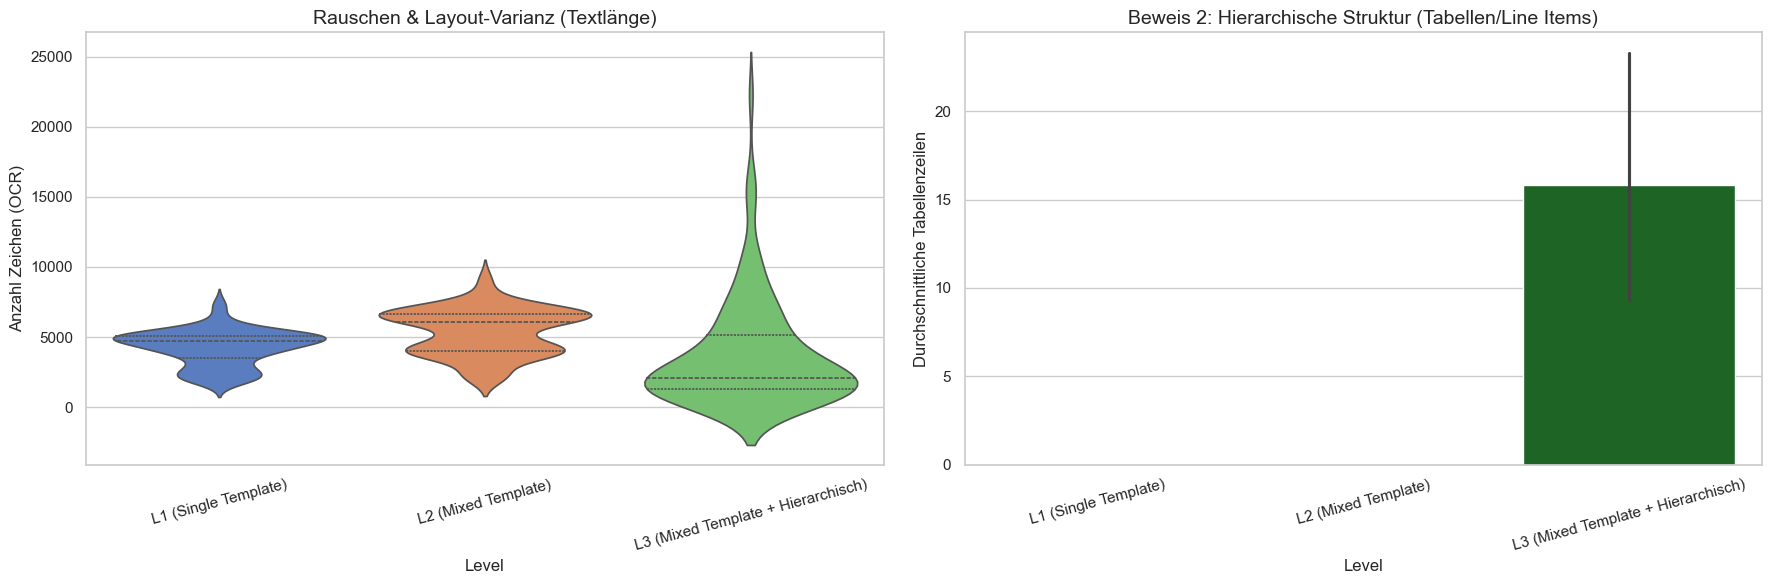

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.violinplot(
    x="Level",
    y="text_length",
    data=df_all,
    ax=axes[0],
    palette="muted",
    inner="quartile",
)
axes[0].set_title("Rauschen & Layout-Varianz (Textlänge)", fontsize=14)
axes[0].set_ylabel("Anzahl Zeichen (OCR)")
axes[0].set_xlabel("Level")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(
    x="Level",
    y="line_items_count",
    data=df_all,
    ax=axes[1],
    palette="dark",
    errorbar=("ci", 95),
)
axes[1].set_title("Beweis 2: Hierarchische Struktur (Tabellen/Line Items)", fontsize=14)
axes[1].set_ylabel("Durchschnittliche Tabellenzeilen")
axes[1].set_xlabel("Level")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

/var/folders/6w/x9kzkbyn6r3_g6mbn02xl3740000gn/T/ipykernel_26619/2668292563.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Level", y="context_per_field", data=df_all, palette="magma")


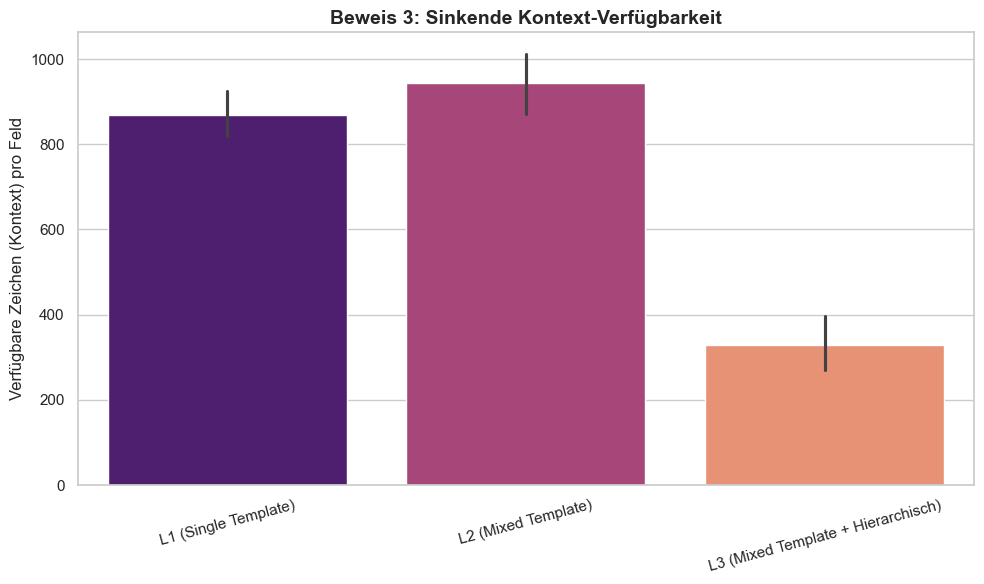

In [85]:
# Wie viele Zeichen Text "erklären" im Schnitt ein Feld?
df_all["context_per_field"] = df_all["text_length"] / (df_all["flat_fields_count"] + 1)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(x="Level", y="context_per_field", data=df_all, palette="magma")

ax.set_title("Beweis 3: Sinkende Kontext-Verfügbarkeit", fontsize=14, fontweight="bold")
ax.set_ylabel("Verfügbare Zeichen (Kontext) pro Feld")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## NLP Methoden

1. Berechnung der lexikalischen Diversität pro Komplexitätsstufe als Type-Token Ratio

In [86]:
import spacy

nlp = spacy.load("en_core_web_lg")

In [87]:
from collections import Counter

def analyse_lexical_complexity(text): 
    doc = nlp(text)

    tokens = [t.text.lower() for t in doc if t.is_alpha]
    ttr = len(set(tokens)) / len(tokens) if tokens else 0
    ent_counts = Counter([ent.label_ for ent in doc.ents])
    ned = len(doc.ents) / len(doc) if len(doc) > 0 else 0

    return{
        "type_token_ratio": round(ttr, 4),
        "entity_density": round(ned, 4),
        "entities": ent_counts
    }

In [88]:
df_l1_metrics = df_l1["content"].apply(analyse_lexical_complexity).apply(pd.Series)

print("L1: TTR und entity density")
print(df_l1_metrics[["type_token_ratio", "entity_density"]].describe())

L1: TTR und entity density
       type_token_ratio  entity_density
count        100.000000      100.000000
mean           0.443081        0.065637
std            0.062148        0.013254
min            0.350400        0.050300
25%            0.397700        0.057800
50%            0.414250        0.062550
75%            0.479025        0.069000
max            0.580400        0.123100


In [89]:
df_l2_metrics = df_l2["content"].apply(analyse_lexical_complexity).apply(pd.Series)

print("L2: TTR und entity density")
print(df_l2_metrics[["type_token_ratio", "entity_density"]].describe())

L2: TTR und entity density
       type_token_ratio  entity_density
count        100.000000      100.000000
mean           0.421101        0.079791
std            0.063656        0.016593
min            0.305100        0.052200
25%            0.379175        0.067675
50%            0.395050        0.073800
75%            0.455400        0.093850
max            0.610200        0.131900


In [90]:
df_l3_metrics = df_l3["content"].apply(analyse_lexical_complexity).apply(pd.Series)

print("L3: TTR und entity density")
print(df_l3_metrics[["type_token_ratio", "entity_density"]].describe())

L3: TTR und entity density
       type_token_ratio  entity_density
count        100.000000      100.000000
mean           0.506595        0.150284
std            0.236341        0.037186
min            0.108200        0.053900
25%            0.268900        0.124000
50%            0.544500        0.150150
75%            0.715925        0.170450
max            0.907000        0.247900



2. NLP: Die "Out-of-Vocabulary" (OOV) Rate

In L1 und L2 begegnen dem Modell immer wieder die gleichen Begriffe, da es sich um die selbe Art von Dokumenten handelt. In L3 kommen plötzlich Begriffe in anderen Sprachen oder branchenspezifische Abkürzungen vor.
Die Untersuchung: Wie viele Wörter in L3 kommen in den Trainingsdaten (L1/L2) überhaupt nicht vor?

Argument: Wenn L3 eine hohe Rate an unbekannten Wörtern hat, versagen klassische Wort-Einbettungen (Word Embeddings). Das Modell muss sich dann auf Zeichenebene oder rein auf das Layout verlassen.

In [91]:
l1_l2_vocab = set()
for df in [df_l1, df_l2]:
    for content in df['content'].dropna():
        doc = nlp(content)
        tokens = [t.text.lower() for t in doc if t.is_alpha]
        l1_l2_vocab.update(tokens)

# Function to calculate OOV rate for a single document
def calculate_oov_rate(content):
    if not isinstance(content, str):
        return 0.0
    doc = nlp(content)
    tokens = [t.text.lower() for t in doc if t.is_alpha]
    oov_count = sum(1 for token in tokens if token not in l1_l2_vocab)
    return oov_count / len(tokens) if tokens else 0.0


df_l3['oov_rate'] = df_l3['content'].apply(calculate_oov_rate)
avg_oov_rate = df_l3['oov_rate'].mean()
print(f"Average OOV Rate in L3 compared to L1/L2: {avg_oov_rate:.4f}")

Average OOV Rate in L3 compared to L1/L2: 0.3932


In [92]:
l3_vocab = set()
for content in df_l3["content"].dropna():
    doc = nlp(content)
    tokens = [t.text.lower() for t in doc if t.is_alpha]
    l3_vocab.update(tokens)


def calculate_reverse_oov_rate(content):
    if not isinstance(content, str):
        return 0.0
    doc = nlp(content)
    tokens = [t.text.lower() for t in doc if t.is_alpha]
    oov_count = sum(1 for token in tokens if token not in l3_vocab)
    return oov_count / len(tokens) if tokens else 0.0


df_l1["oov_rate_vs_l3"] = df_l1["content"].apply(calculate_reverse_oov_rate)
df_l2["oov_rate_vs_l3"] = df_l2["content"].apply(calculate_reverse_oov_rate)

print(f"Average OOV Rate in L1 compared to L3: {df_l1['oov_rate_vs_l3'].mean():.4f}")
print(f"Average OOV Rate in L2 compared to L3: {df_l2['oov_rate_vs_l3'].mean():.4f}")

Average OOV Rate in L1 compared to L3: 0.1777
Average OOV Rate in L2 compared to L3: 0.2019


3. CV: Relative 2D-Positionen (Spatial Awareness)

Da in L3 der Textkontext fehlt (dein letzter Plot), muss das Modell die geometrische Beziehung nutzen.
Die Untersuchung: Berechne die Distanz (in Pixeln) zwischen einem Label (z.B. "Summe") und dem zugehörigen Wert.

Argument: In L1/L2 sind diese Abstände oft konstant. In L3 variieren sie stark oder das Label fehlt völlig. Du könntest untersuchen, wie weit "Key" und "Value" im 2D-Raum auseinanderliegen. Je größer die Varianz dieser Distanz, desto schwieriger ist die Extraktion für ein Computer-Vision-Modell.

In [93]:
def calculate_bbox_distances(ground_truth_raw):
    """
    Berechnet die paarweisen Euclidean-Distanzen zwischen den Zentren der Bounding Boxes
    aller field_extractions in einem DocILE-Dokument.
    Gibt Mittelwert und Standardabweichung der Distanzen zurück.
    """
    if not isinstance(ground_truth_raw, dict) or 'field_extractions' not in ground_truth_raw:
        return None, None
    
    bboxes = []
    for field in ground_truth_raw['field_extractions']:
        if 'bbox' in field:
            bbox = field['bbox']

            center_x = (bbox[0] + bbox[2]) / 2
            center_y = (bbox[1] + bbox[3]) / 2
            bboxes.append((center_x, center_y))
    
    if len(bboxes) < 2:
        return 0, 0
    
    distances = []
    for i in range(len(bboxes)):
        for j in range(i+1, len(bboxes)):
            dist = np.sqrt((bboxes[i][0] - bboxes[j][0])**2 + (bboxes[i][1] - bboxes[j][1])**2)
            distances.append(dist)
    
    if distances:
        mean_dist = np.mean(distances)
        std_dist = np.std(distances)
        return mean_dist, std_dist
    return 0, 0

df_l3_docile = df_l3[df_l3['metadata'].apply(lambda x: x.get('source') == 'DocILE')]

df_l3_docile = df_l3_docile.copy()
df_l3_docile['bbox_distances'] = df_l3_docile['ground_truth_raw'].apply(calculate_bbox_distances)

df_l3_docile['mean_distance'] = df_l3_docile['bbox_distances'].apply(lambda x: x[0])
df_l3_docile['std_distance'] = df_l3_docile['bbox_distances'].apply(lambda x: x[1])

print("Statistik der paarweisen Distanzen zwischen Feld-Bounding Boxes in L3 DocILE:")
print(df_l3_docile[['mean_distance', 'std_distance']].describe())

Statistik der paarweisen Distanzen zwischen Feld-Bounding Boxes in L3 DocILE:
       mean_distance  std_distance
count      50.000000     50.000000
mean        0.449475      0.252876
std         0.089106      0.052461
min         0.265293      0.128213
25%         0.399513      0.224279
50%         0.455549      0.255727
75%         0.495060      0.279596
max         0.622830      0.376019
